# Matplotlib + Seaborn

In [6]:
import pandas as pd

In [12]:
df=pd.read_csv("C:\\Users\\ywako\\Downloads\\Hotel_booking_dataset - Hotel_booking_dataset.csv")
df

,Booking ID,Customer Name,Booking Date,City,Room Type,Booking Channel,Customer Segment,Gender,Age,Room Nights,...,Rating,Guests,Is Member,Cancelled,Payment Method,Gross Amount,Discount Amount,Final Amount,Hotel Cost,Profit
0,BKG01888,Customer_1888,2025-05-17 00:00:00,Mumbai,Suite,Online,Premium,Male,39,4,...,1.4,2,1,0,Credit Card,31674.48,2096.850576,29577.629420,16901.386250,12676.243170
1,BKG00789,Customer_0789,2025-07-29 00:00:00,Bengaluru,Suite,Walk-in,Corporate,Male,25,1,...,2.5,2,1,0,Credit Card,4822.39,735.414475,4086.975525,2746.904163,1340.071362
2,BKG00757,Customer_0757,2025-10-19 00:00:00,Pune,Suite,Corporate,Corporate,Other,50,4,...,1.2,1,0,1,Credit Card,66334.52,15575.345300,50759.174700,40212.657470,10546.517240
3,BKG01079,Customer_1079,2025-12-14 00:00:00,Mumbai,Deluxe,Walk-in,Regular,Male,53,3,...,2.6,6,0,0,Debit Card,19255.92,5328.113064,13927.806940,9639.061764,4288.745172
4,BKG00218,Customer_0218,2025-01-20 00:00:00,Delhi,Suite,Travel Agent,Budget,Male,38,NaN,...,4.2,4,1,0,Cash,15685.38,5160.490020,10524.889980,6545.581304,3979.308676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,BKG01738,Customer_1738,2025-11-27 00:00:00,Hyderabad,Deluxe,Online,Premium,Other,52,3,...,4,4,1,0,Net Banking,12777.78,204.444480,12573.335520,9277.794053,3295.541467
2021,BKG01193,Customer_1193,2025-10-22 00:00:00,Hyderabad,Deluxe,Online,Premium,Male,33,5,...,4.7,5,1,1,Net Banking,51298.55,17574.883230,33723.666770,22307.978330,11415.688440
2022,BKG01210,Customer_1210,2025-07-11 00:00:00,Mumbai,Deluxe,Online,Premium,Male,48,6,...,1.3,6,1,0,Debit Card,79546.56,23108.275680,56438.284320,36544.131720,19894.152600
2023,BKG01060,Customer_1060,2025-01-24 00:00:00,Hyderabad,Executive,Travel Agent,Budget,Female,52,2,...,3.8,2,1,1,Debit Card,18041.10,5910.264360,12130.835640,9683.417958,2447.417682


#### 1. Histogram of Age What to plot: Distribution of customer agesColumns: Age Required: Age should be numeric and cleaned (remove text like “30 yrs”, impossible values) Easy explanation: Shows how many customers fall in different age groups (young, middle- aged, old).

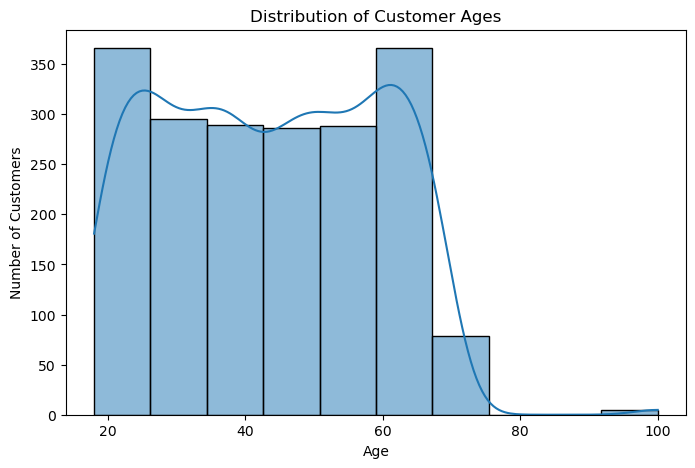

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df["Age"] = pd.to_numeric(
    df["Age"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)
df.loc[(df["Age"] < 0) | (df["Age"] > 100), "Age"] = pd.NA
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Age"].dropna(),
    bins=10,
    kde=True
)
plt.title("Distribution of Customer Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

#### 2. Count Plot of Room Type What to plot: Number of bookings for each room type Columns: Room Type Required: Room Type cleaned and standardized (Deluxe, Suite, Standard, Executive) Easy explanation: Quickly tells which room type is booked the most.

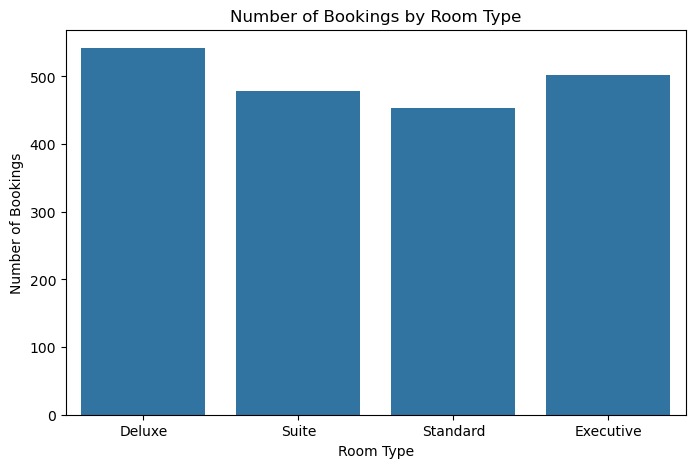

In [14]:
df["Room Type"] = (
    df["Room Type"]
    .astype(str)
    .str.strip()
    .str.title()
)
room_mapping = {
    "Deluxe Room": "Deluxe",
    "Deluxe": "Deluxe",
    "Suite Room": "Suite",
    "Suite": "Suite",
    "Standard Room": "Standard",
    "Standard": "Standard",
    "Executive Room": "Executive",
    "Executive": "Executive"
}
df["Room Type"] = df["Room Type"].replace(room_mapping)
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Room Type",
    order=["Deluxe", "Suite", "Standard", "Executive"]
)
plt.title("Number of Bookings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.show()

#### 3. Bar Plot of Average Final Amount by City What to plot: Average spending (Final Amount) in each city Columns: City, Final Amount Required: City cleaned, Final Amount numeric Easy explanation: Shows which city generates higher average revenue.

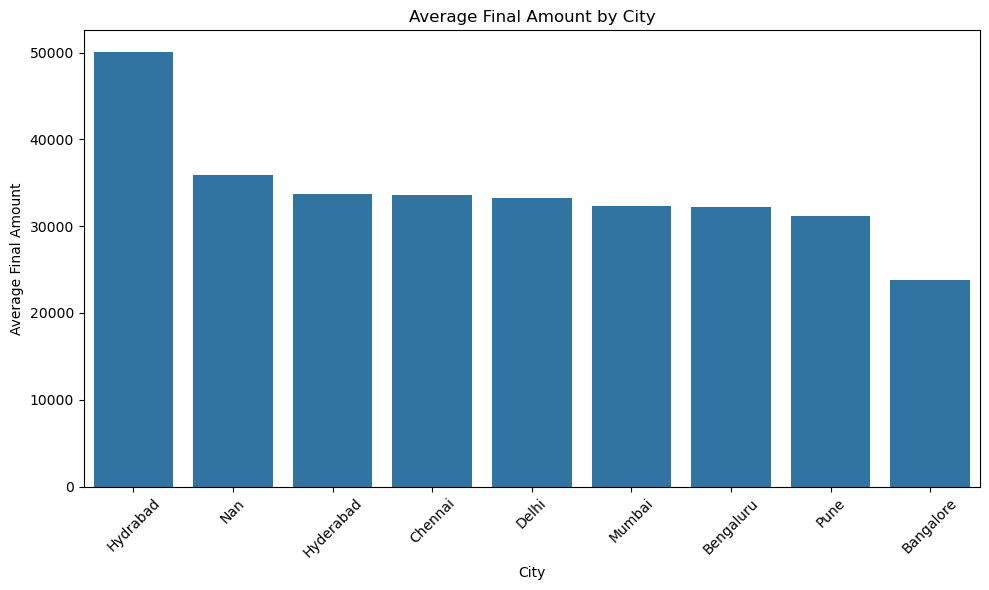

In [15]:
df["City"] = (
    df["City"]
    .astype(str)
    .str.strip()
    .str.title()
)
df["Final Amount"] = pd.to_numeric(
    df["Final Amount"],
    errors="coerce"
)
city_avg = (
    df.groupby("City")["Final Amount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=city_avg,
    x="City",
    y="Final Amount"
)
plt.title("Average Final Amount by City")
plt.xlabel("City")
plt.ylabel("Average Final Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4. Box Plot of Room Rate by Room Type What to plot: Spread and outliers of room rates for each room type Columns: Room Type, Room Rate Required: Both columns cleaned, Room Rate numeric Easy explanation: Helps see which room type is generally expensive and if there are unusual high/low prices.

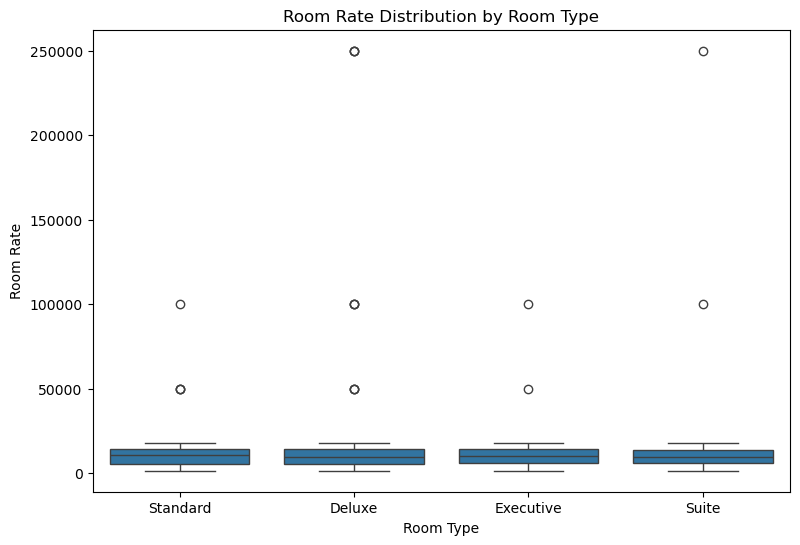

In [16]:
df["Room Type"] = (
    df["Room Type"]
    .astype(str)
    .str.strip()
    .str.title()
)
room_mapping = {
    "Deluxe Room": "Deluxe",
    "Deluxe": "Deluxe",
    "Suite Room": "Suite",
    "Suite": "Suite",
    "Standard Room": "Standard",
    "Standard": "Standard",
    "Executive Room": "Executive",
    "Executive": "Executive"
}
df["Room Type"] = df["Room Type"].replace(room_mapping)
df["Room Rate"] = pd.to_numeric(
    df["Room Rate"],
    errors="coerce"
)
plot_data = df.dropna(subset=["Room Type", "Room Rate"])
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=plot_data,
    x="Room Type",
    y="Room Rate",
    order=["Standard", "Deluxe", "Executive", "Suite"]
)
plt.title("Room Rate Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Room Rate")
plt.show()

#### 5. Count Plot of Booking Channel What to plot: How many bookings came from each channel Columns: Booking Channel Required: Channel names standardized (Online, Walk-in, Corporate, Travel Agent) Easy explanation: Shows which booking method is most popular.

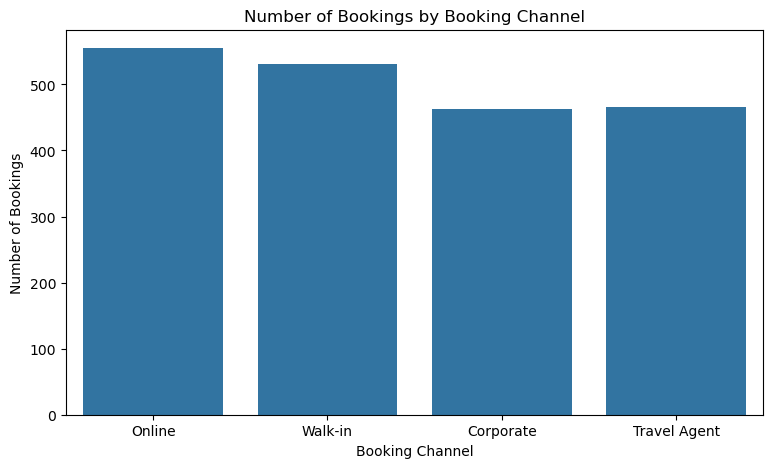

In [17]:
df["Booking Channel"] = (
    df["Booking Channel"]
    .astype(str)
    .str.strip()
    .str.title()
)
channel_mapping = {
    "Online Booking": "Online",
    "Online": "Online",
    "Walk In": "Walk-in",
    "Walk-In": "Walk-in",
    "Walkin": "Walk-in",
    "Corporate Booking": "Corporate",
    "Corporate": "Corporate",
    "Travel Agent Booking": "Travel Agent",
    "Travel Agent": "Travel Agent"
}
df["Booking Channel"] = df["Booking Channel"].replace(channel_mapping)
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Booking Channel",
    order=["Online", "Walk-in", "Corporate", "Travel Agent"]
)
plt.title("Number of Bookings by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Number of Bookings")
plt.show()

#### 6. Histogram of Room NightsWhat to plot: How long customers usually stayColumns: Room Nights Required: Room Nights converted to numbers (remove “3 nights”, “N/A”) Easy explanation: Tells whether most people stay 1–2 nights or longer.

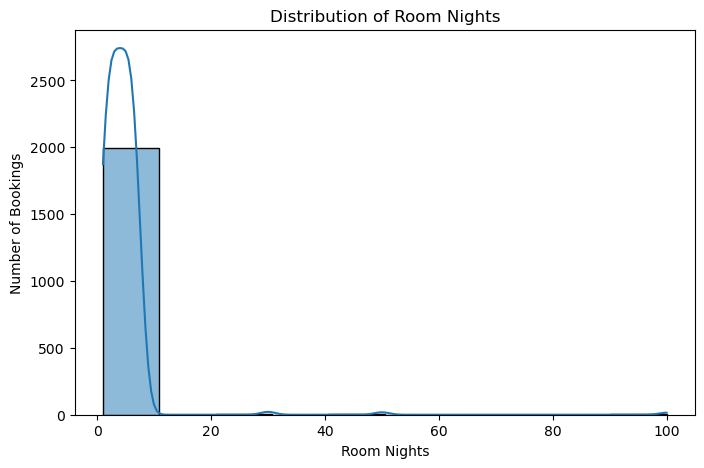

In [18]:
df["Room Nights"] = pd.to_numeric(
    df["Room Nights"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)
df.loc[df["Room Nights"] <= 0, "Room Nights"] = pd.NA
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Room Nights"].dropna(),
    bins=10,
    kde=True
)
plt.title("Distribution of Room Nights")
plt.xlabel("Room Nights")
plt.ylabel("Number of Bookings")
plt.show()

#### 7. Bar Plot of Cancellation Rate by Customer Segment What to plot: Percentage of cancelled bookings in each segment Columns: Customer Segment, Cancelled Required: Cancelled cleaned to 0/1, Segment standardized Easy explanation: Shows which customer group cancels more often.

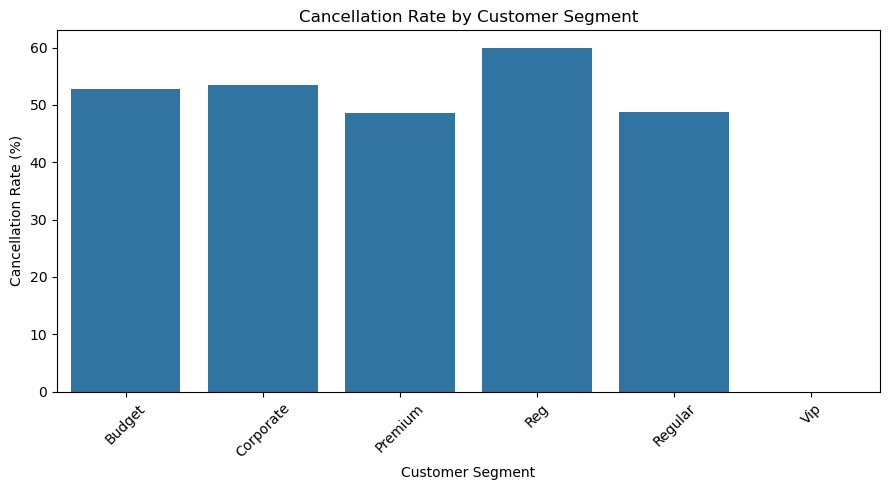

In [19]:
df["Customer Segment"] = (
    df["Customer Segment"]
    .astype(str)
    .str.strip()
    .str.title()
)
cancel_mapping = {
    "Yes": 1,
    "No": 0,
    "Cancelled": 1,
    "Canceled": 1,
    "True": 1,
    "False": 0
}
df["Cancelled"] = (
    df["Cancelled"]
    .replace(cancel_mapping)
)
df["Cancelled"] = pd.to_numeric(
    df["Cancelled"],
    errors="coerce"
)
cancellation_rate = (
    df.groupby("Customer Segment")["Cancelled"]
    .mean()
    .mul(100)
    .reset_index()
)
plt.figure(figsize=(9, 5))
sns.barplot(
    data=cancellation_rate,
    x="Customer Segment",
    y="Cancelled"
)
plt.title("Cancellation Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 8. Box Plot of Age by Gender What to plot: Age distribution of Male vs Female customers Columns: Gender, Age Required: Gender standardized (Male/Female/Other), Age numeric Easy explanation: Checks if one gender is generally younger or older.

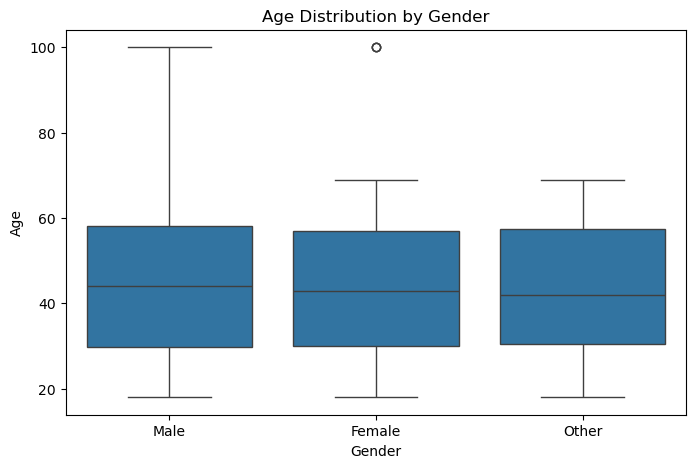

In [20]:
df["Gender"] = (
    df["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
)
gender_mapping = {
    "M": "Male",
    "Male": "Male",
    "F": "Female",
    "Female": "Female",
    "O": "Other",
    "Other": "Other"
}
df["Gender"] = df["Gender"].replace(gender_mapping)
df["Age"] = pd.to_numeric(
    df["Age"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)
df.loc[(df["Age"] < 0) | (df["Age"] > 100), "Age"] = pd.NA
plot_data = df.dropna(subset=["Gender", "Age"])
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_data,
    x="Gender",
    y="Age",
    order=["Male", "Female", "Other"]
)
plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

#### 9. Count Plot of Payment Method What to plot: Popularity of different payment methods Columns: Payment Method Required: Payment Method cleaned and standardized Easy explanation: Shows whether Credit Card, UPI, Cash etc. is used more.

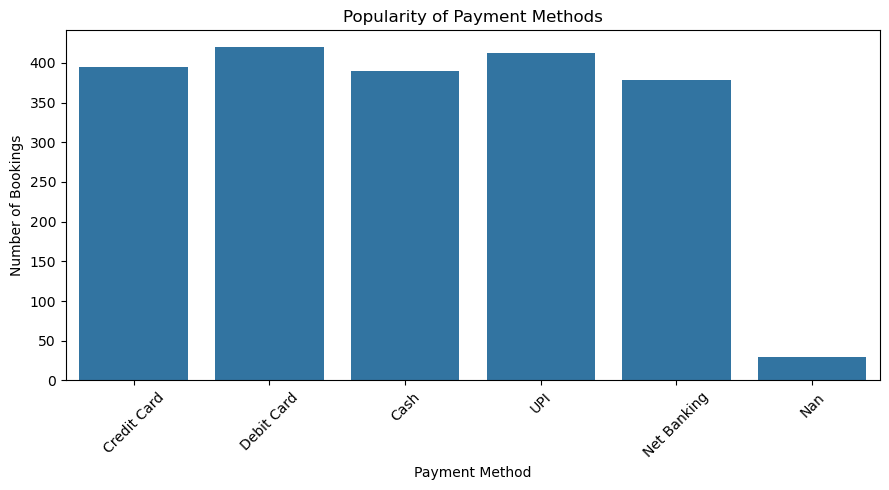

In [21]:
df["Payment Method"] = (
    df["Payment Method"]
    .astype(str)
    .str.strip()
    .str.title()
)
payment_mapping = {
    "Credit Card": "Credit Card",
    "Creditcard": "Credit Card",
    "Card": "Credit Card",
    "Upi": "UPI",
    "UPI": "UPI",
    "Cash": "Cash",
    "Cash Payment": "Cash",
    "Debit Card": "Debit Card",
    "Debitcard": "Debit Card",
    "Net Banking": "Net Banking",
    "Netbanking": "Net Banking"
}
df["Payment Method"] = df["Payment Method"].replace(payment_mapping)
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Payment Method"
)
plt.title("Popularity of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 10. Scatter Plot of Room Rate vs Final Amount What to plot: Relationship between room rate and total amount paid Columns: Room Rate, Final Amount Required: Both columns numeric and cleaned Easy explanation: Checks if higher room rates lead to higher final bills.

In [ ]:
df["Room Rate"] = pd.to_numeric(
df["Room Rate"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)
df["Final Amount"] = pd.to_numeric(
    df["Final Amount"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)
plot_data = df.dropna(subset=["Room Rate", "Final Amount"])
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_data,
    x="Room Rate",
    y="Final Amount"
)

plt.title("Room Rate vs Final Amount")
plt.xlabel("Room Rate")
plt.ylabel("Final Amount")
plt.grid(alpha=0.3)

plt.show()